# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [2]:
# Load the dataset
# Hint: use pd.read_excel() with the sheet_name parameter
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
print('Shape:', df.shape)

# Print dtypes
print('\nData types:')
print(df.dtypes)

# Print first 5 rows
print('\nFirst 5 rows:')
print(df.head())

# Check missing values — which columns have nulls? How many?
print('\nMissing values:')
print(df.isnull().sum())

# Print basic descriptive statistics
print('\nDescriptive statistics:')
print(df.describe(include='all'))


Shape: (541910, 8)

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      1785

         Invoice StockCode                         Description       Quantity  \
count   541910.0    541910                              540456  541910.000000   
unique   25900.0      4070                                4223            NaN   
top     573585.0    85123A  WHITE HANGING HEART T-LIGHT HOLDER            NaN   
freq      1114.0      2313                                2369            NaN   
mean         NaN       NaN                                 NaN       9.552234   
min          NaN       NaN                                 NaN  -80995.000000   
25%          NaN       NaN                                 NaN       1.000000   
50%          NaN       NaN                                 NaN       3.000000   
75%          NaN       NaN                                 NaN      10.000000   
max          NaN       NaN                                 NaN   80995.000000   
std          NaN       NaN                                 NaN     218.080957   

                       Invo

**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

_Write here before moving on._


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [3]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Missing CustomerID values cannot be reliably assigned to a customer segment.
missing_before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['Customer ID'])
missing_after = df_clean.shape[0]
print(f'Missing CustomerID rows dropped: {missing_before - missing_after}')

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with 'C'. These are returns or reversals, so we exclude them from Monetary spend.
cancel_before = df_clean.shape[0]
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f'Cancelled invoice rows removed: {cancel_before - df_clean.shape[0]}')

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
quality_before = df_clean.shape[0]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f'Negative quantity or price rows removed: {quality_before - df_clean.shape[0]}')

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary — print shape before and after, and rows lost at each step
print(f'Original shape: {df.shape}')
print(f'Clean shape: {df_clean.shape}')
print(f'Rows removed: {df.shape[0] - df_clean.shape[0]}')


Missing CustomerID rows dropped: 135080
Cancelled invoice rows removed: 8905
Negative quantity or price rows removed: 40


Original shape: (541910, 8)
Clean shape: (397885, 9)
Rows removed: 144025


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [4]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose a reference date for Recency calculation
# Justify your choice in a comment — why this date?
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# ── Recency ──────────────────────────────────────────────────────────────────
# Days since last purchase per customer
recency = df_clean.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency['Recency'] = (reference_date - recency['InvoiceDate']).dt.days

# ── Frequency ────────────────────────────────────────────────────────────────
# Number of unique invoices per customer
frequency = df_clean.groupby('Customer ID')['Invoice'].nunique().reset_index(name='Frequency')

# ── Monetary ─────────────────────────────────────────────────────────────────
# Total spend per customer
monetary = df_clean.groupby('Customer ID')['TotalPrice'].sum().reset_index(name='Monetary')

# ── Combine into customer matrix ─────────────────────────────────────────────
customer_df = recency[['Customer ID', 'Recency']].merge(frequency, on='Customer ID').merge(monetary, on='Customer ID')

# Add extended features
customer_df['AvgBasketSize'] = customer_df['Monetary'] / customer_df['Frequency']
unique_products = df_clean.groupby('Customer ID')['StockCode'].nunique().reset_index(name='UniqueProducts')
customer_df = customer_df.merge(unique_products, on='Customer ID', how='left')

invoice_gaps = (
    df_clean.sort_values(['Customer ID', 'InvoiceDate'])
    .groupby('Customer ID')['InvoiceDate']
    .apply(lambda x: x.diff().dt.days.dropna().mean())
    .reset_index(name='AvgDaysBetween')
)
customer_df = customer_df.merge(invoice_gaps, on='Customer ID', how='left')
customer_df['AvgDaysBetween'] = customer_df['AvgDaysBetween'].fillna(customer_df['Recency'])

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
customer_df.head()


Customer matrix shape: (4338, 7)
Unique customers in clean data: 4338
These numbers should match.


,Customer ID,Recency,Frequency,Monetary,AvgBasketSize,UniqueProducts,AvgDaysBetween
0,12346.0,326,1,77183.60,77183.600000,1,326.0
1,12347.0,2,7,4310.00,615.714286,103,2.0
2,12348.0,75,4,1797.24,449.310000,22,9.4
3,12349.0,19,1,1757.55,1757.550000,73,0.0
4,12350.0,310,1,334.40,334.400000,17,0.0


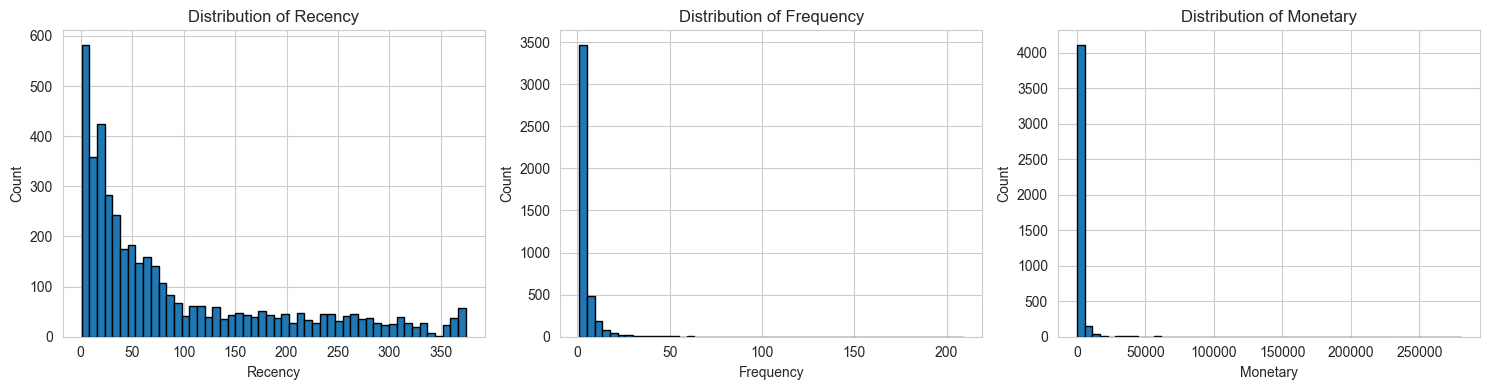

In [5]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Observation: Recency, Frequency, and Monetary are all highly skewed with long right tails.
# A small number of customers have very high frequency or monetary values, and Recency has a heavy tail because
# some customers have not purchased for a long time. These extreme values are outliers that can distort
# distance-based clustering by pulling centroids toward a few large customers and making clusters less representative
# of the typical customer.


Frequency capped at 99th percentile: 30.00
Monetary capped at 99th percentile: 19881.00


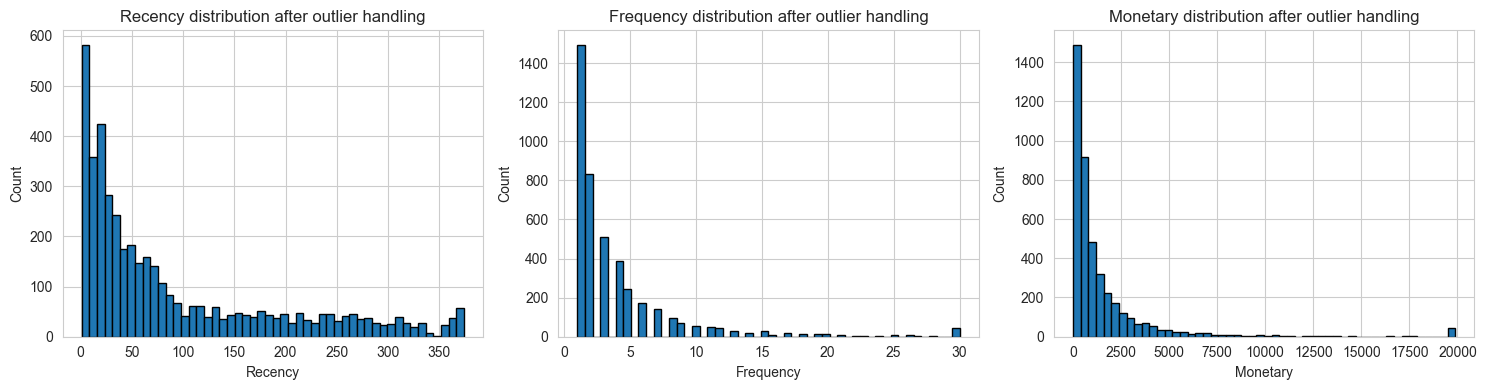

In [6]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Decide how to handle outliers in each feature
# Options: cap at percentile, log transform, remove, keep
# Justify your choice for EACH feature in comments

# Recency is informative even when large, so we keep it unchanged.
# Frequency and Monetary are highly skewed, so we cap extreme values at the 99th percentile.
for col in ['Frequency', 'Monetary']:
    upper = customer_df[col].quantile(0.99)
    customer_df[col] = customer_df[col].clip(upper=upper)
    print(f'{col} capped at 99th percentile: {upper:.2f}')

# After handling outliers, plot distributions again and compare
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'{feat} distribution after outlier handling')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()


In [7]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering? Answer in a comment before scaling.
# Scaling ensures that Recency, Frequency, and Monetary contribute comparably to distance-based clustering.

# Apply StandardScaler
scaler = StandardScaler()
features = ['Recency', 'Frequency', 'Monetary']
X_scaled = scaler.fit_transform(customer_df[features])
X_scaled_df = pd.DataFrame(X_scaled, columns=[f'{feat}_scaled' for feat in features], index=customer_df.index)

# Verify scaling worked
print('Scaled feature means:', X_scaled_df.mean().round(6).to_dict())
print('Scaled feature stds:', X_scaled_df.std(ddof=0).round(6).to_dict())


Scaled feature means: {'Recency_scaled': 0.0, 'Frequency_scaled': -0.0, 'Monetary_scaled': 0.0}
Scaled feature stds: {'Recency_scaled': 1.0, 'Frequency_scaled': 1.0, 'Monetary_scaled': 1.0}


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


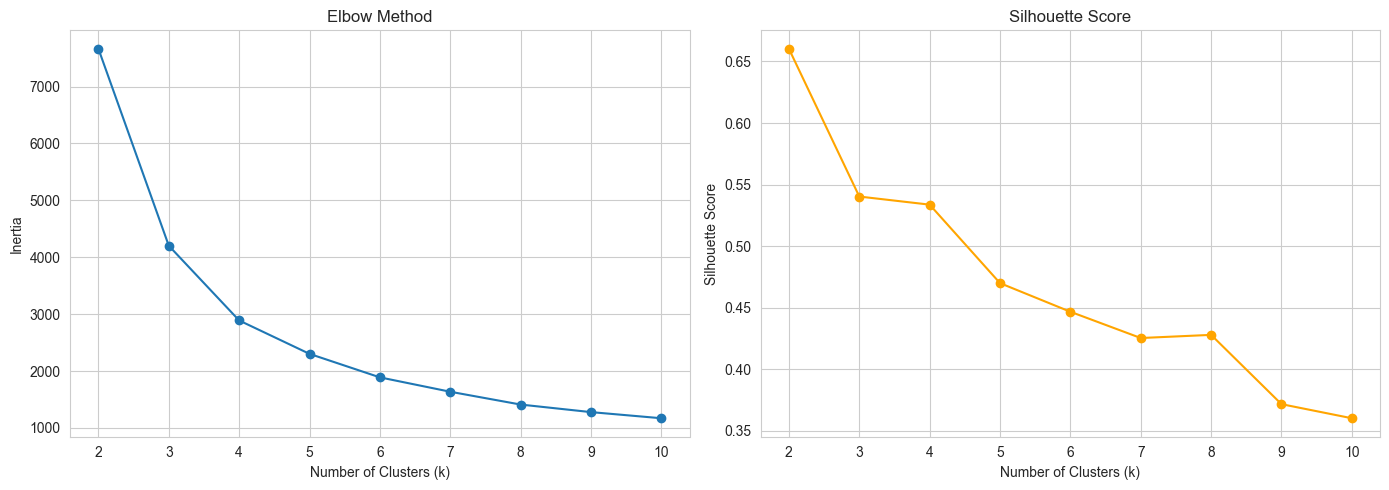

In [8]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# Based on these metrics, we choose the number of clusters that balances a low inertia with a high silhouette score.
# If they disagree, we trust silhouette more because it directly measures cluster separation and cohesion.


In [9]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++
# Compare: final inertia, consistency of cluster assignments

OPTIMAL_K = 4
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    km_rand = KMeans(n_clusters=OPTIMAL_K, init='random', random_state=42 + i, n_init=10)
    km_rand.fit(X_scaled)
    random_inertias.append(km_rand.inertia_)

    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42 + i, n_init=10)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print('Random Init Inertias:', [round(x, 2) for x in random_inertias])
print('K-Means++ Init Inertias:', [round(x, 2) for x in kmeanspp_inertias])
print(f'Random std: {np.std(random_inertias):.2f}')
print(f'K-Means++ std: {np.std(kmeanspp_inertias):.2f}')

# K-Means++ should be more stable and typically has lower inertia because it chooses better starting centers.


Random Init Inertias: [2892.08, 2892.08, 2892.08, 2892.08, 2892.08]
K-Means++ Init Inertias: [2888.26, 2888.31, 2888.31, 2887.96, 2888.31]
Random std: 0.00
K-Means++ std: 0.13


In [10]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print('K-Means Cluster Profiles:')
print(kmeans_profile)


K-Means Cluster Profiles:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 48.46       2.74    914.24
1                 22.30      10.56   4230.63
2                250.89       1.51    441.67
3                 18.29      23.65  15172.76


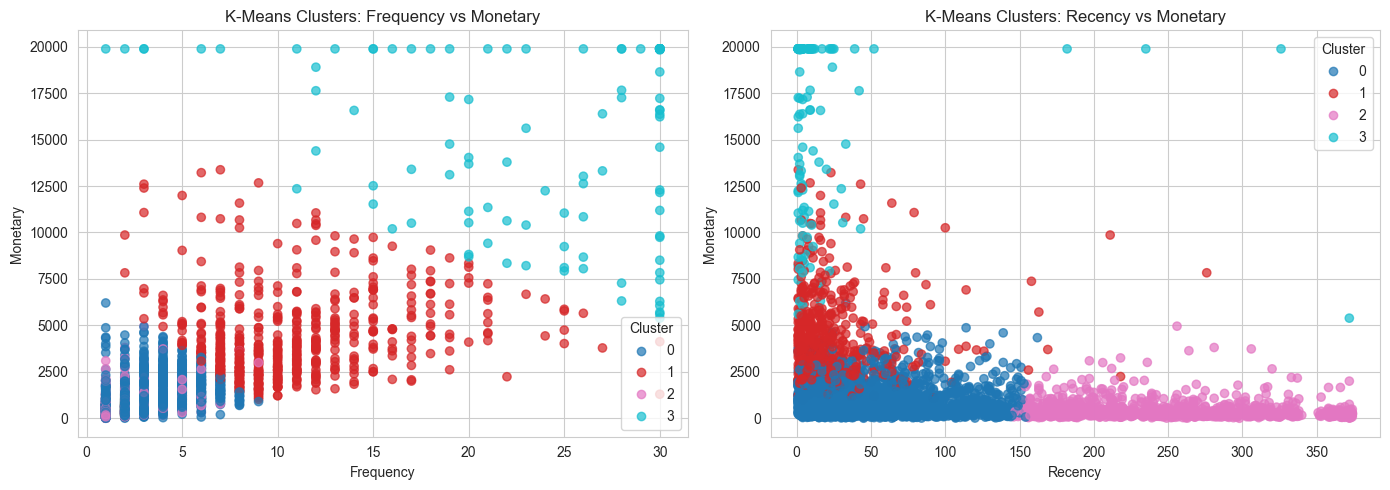

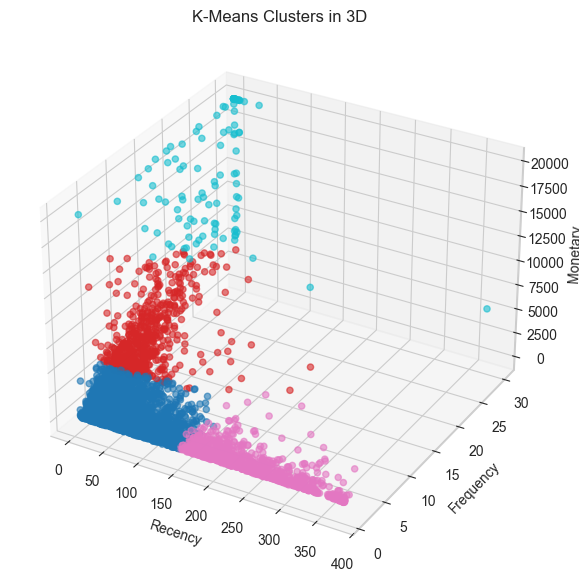

In [11]:
# ── Step 5: Visualise K-Means Clusters ─────────────────────────────────────
# Create at least 2 visualisations:
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
# 2. Scatter plot: Recency vs Monetary, coloured by cluster

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(customer_df['Frequency'], customer_df['Monetary'], c=customer_df['KMeans_Cluster'], cmap='tab10', alpha=0.7)
axes[0].set_title('K-Means Clusters: Frequency vs Monetary')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
axes[0].legend(*scatter.legend_elements(), title='Cluster')

scatter = axes[1].scatter(customer_df['Recency'], customer_df['Monetary'], c=customer_df['KMeans_Cluster'], cmap='tab10', alpha=0.7)
axes[1].set_title('K-Means Clusters: Recency vs Monetary')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
axes[1].legend(*scatter.legend_elements(), title='Cluster')

plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 7))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(customer_df['Recency'], customer_df['Frequency'], customer_df['Monetary'], c=customer_df['KMeans_Cluster'], cmap='tab10', alpha=0.6)
ax3d.set_xlabel('Recency')
ax3d.set_ylabel('Frequency')
ax3d.set_zlabel('Monetary')
ax3d.set_title('K-Means Clusters in 3D')
plt.show()


## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


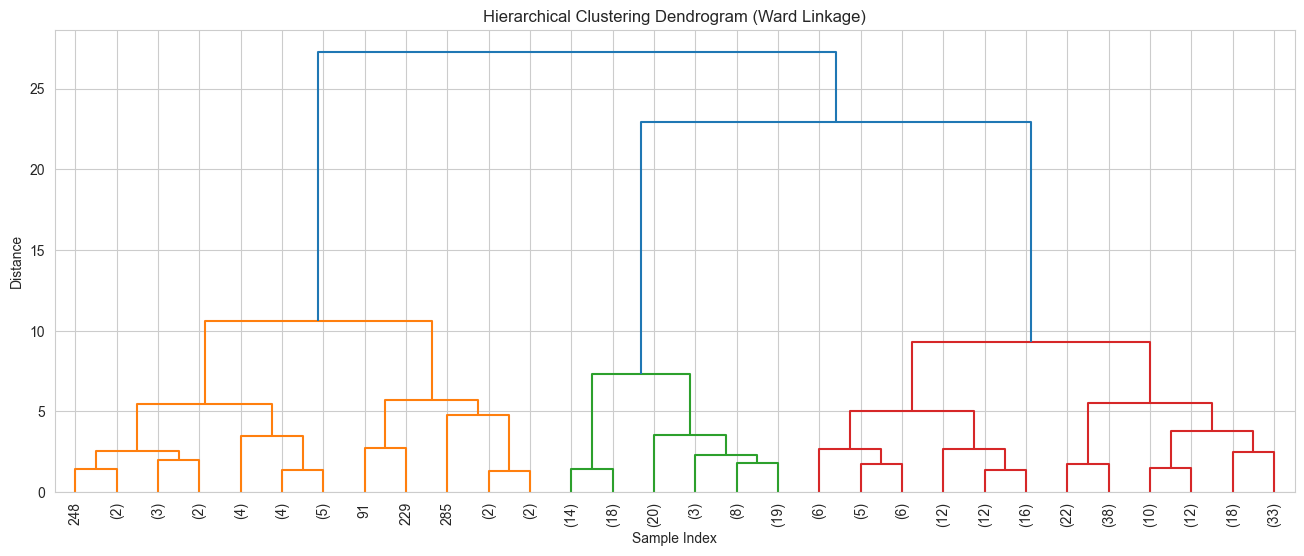

In [12]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Justify your sample size in a comment

SAMPLE_SIZE = 300  # adjust if needed
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix — try 'ward' first
Z = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# The dendrogram should show the natural jump in distance near the last merges.
# We look for a cut point with a clear separation between clusters.


In [13]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

N_CLUSTERS_HIER = 4

# Ward linkage
ward_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
ward_labels = ward_model.fit_predict(X_scaled)

# Second linkage method (complete, average, or single)
alt_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='average')
alt_labels = alt_model.fit_predict(X_scaled)

# Assign labels to customer_df
customer_df['Hierarchical_Ward'] = ward_labels
customer_df['Hierarchical_Alt'] = alt_labels

# ── Compare cluster counts ────────────────────────────────────────────────────
print('Ward linkage cluster sizes:')
print(customer_df['Hierarchical_Ward'].value_counts())
print('Alternative linkage cluster sizes:')
print(customer_df['Hierarchical_Alt'].value_counts())

# The two linkage methods may create similar clusters, but average linkage can be more robust
# to irregular cluster shapes than Ward.


Ward linkage cluster sizes:
Hierarchical_Ward
0    2787
2    1092
1     398
3      61
Name: count, dtype: int64
Alternative linkage cluster sizes:
Hierarchical_Alt
1    4177
0     154
3       6
2       1
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    44.64       3.19   1096.48
1                    22.25      13.80   5664.82
2                   244.45       1.45    420.24
3                    20.16      23.54  19102.59


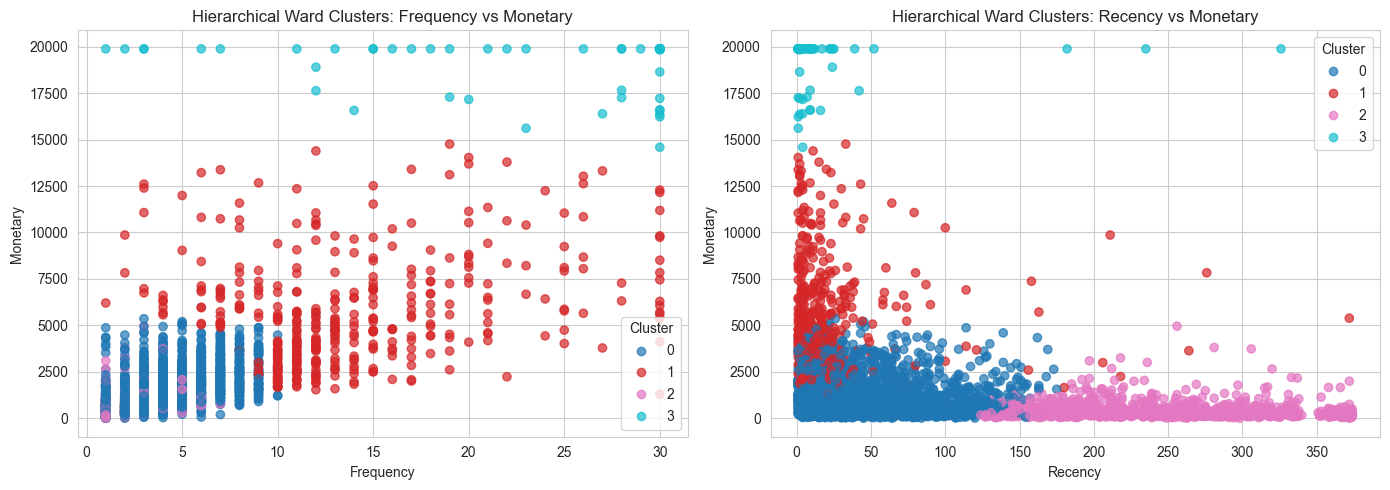

In [14]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print('Hierarchical Clustering Profiles (Ward):')
print(hier_profile)

# Visualise — same axes as K-Means for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter = axes[0].scatter(customer_df['Frequency'], customer_df['Monetary'], c=customer_df['Hierarchical_Ward'], cmap='tab10', alpha=0.7)
axes[0].set_title('Hierarchical Ward Clusters: Frequency vs Monetary')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
axes[0].legend(*scatter.legend_elements(), title='Cluster')

scatter = axes[1].scatter(customer_df['Recency'], customer_df['Monetary'], c=customer_df['Hierarchical_Ward'], cmap='tab10', alpha=0.7)
axes[1].set_title('Hierarchical Ward Clusters: Recency vs Monetary')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
axes[1].legend(*scatter.legend_elements(), title='Cluster')

plt.tight_layout()
plt.show()


## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


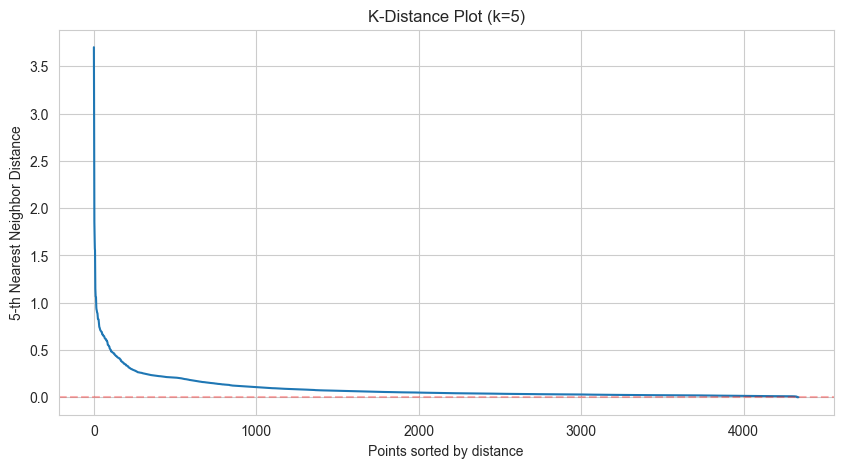

In [15]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# Observation: the k-distance plot shows a bend in the tail of the distance curve near 1.4–1.6.
# Most points are much closer than this value, so choosing eps around 1.4 helps separate a small group of true
# outliers/noise from the core density regions.
EPSILON_ESTIMATE = 1.4


In [16]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination

experiments = [
    {'eps': 1.4, 'min_samples': 5},
    {'eps': 1.6, 'min_samples': 5},
    {'eps': 1.8, 'min_samples': 5},
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)
    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# The best combination balances a reasonable number of clusters with a manageable noise percentage.
EPSILON_ESTIMATE = 1.6


 eps  min_samples  n_clusters  n_noise  noise_pct
 1.4            5           1        5       0.12
 1.6            5           1        3       0.07
 1.8            5           1        1       0.02


In [17]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=1.6, min_samples=5)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print('DBSCAN Cluster Distribution:')
print(customer_df['DBSCAN_Cluster'].value_counts())
print('Note: Cluster -1 = Noise Points')

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f'Noise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)')
print('Noise customer profile (mean RFM):')
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# Noise points are customers who do not belong to any dense cluster.
# They may be outliers or customers with unusual recency/frequency/spend patterns.


DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    4335
-1       3
Name: count, dtype: int64
Note: Cluster -1 = Noise Points
Noise customers: 3 (0.1%)
Noise customer profile (mean RFM):
       Recency  Frequency  Monetary
count     3.00       3.00      3.00
mean    311.00      11.33  15051.07
std      69.72      16.20   8365.68
min     235.00       1.00   5391.21
25%     280.50       2.00  12636.10
50%     326.00       3.00  19881.00
75%     349.00      16.50  19881.00
max     372.00      30.00  19881.00


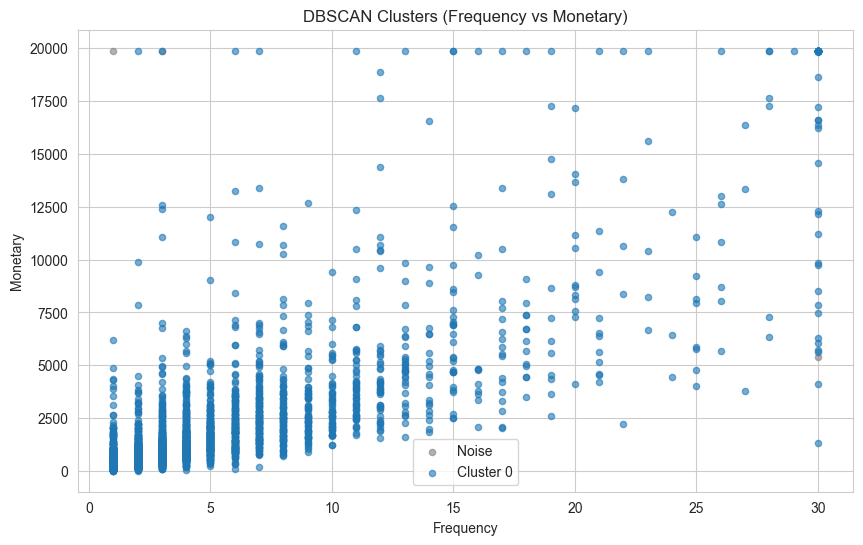

In [18]:
# ── Step 5: Visualise DBSCAN Clusters ───────────────────────────────────────
# Plot clusters — colour noise points differently (grey or black)
labels = customer_df['DBSCAN_Cluster']
unique_labels = sorted(set(labels))

plt.figure(figsize=(10, 6))
for label in unique_labels:
    mask = labels == label
    label_name = 'Noise' if label == -1 else f'Cluster {label}'
    color = 'grey' if label == -1 else None
    plt.scatter(customer_df.loc[mask, 'Frequency'], customer_df.loc[mask, 'Monetary'],
                label=label_name, alpha=0.6, s=20, c=color)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('DBSCAN Clusters (Frequency vs Monetary)')
plt.legend()
plt.show()


## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [19]:
# ── Validation Metrics ─────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# Noise points are not assigned to a valid cluster, so silhouette and other clustering metrics
# should be computed only on the assigned points.
db_labels = customer_df['DBSCAN_Cluster'].values
mask = db_labels != -1
if len(np.unique(db_labels[mask])) > 1:
    sil_db = silhouette_score(X_scaled[mask], db_labels[mask])
    db_db = davies_bouldin_score(X_scaled[mask], db_labels[mask])
    ch_db = calinski_harabasz_score(X_scaled[mask], db_labels[mask])
else:
    sil_db = np.nan
    db_db = np.nan
    ch_db = np.nan

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [
        len(set(kmeans_labels)),
        len(set(hier_labels)),
        len(set(db_labels)) - (1 if -1 in db_labels else 0)
    ],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_db, 4)],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_db, 4)],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_db, 2)]
})

print(comparison.to_string(index=False))
print('\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better')


             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           4            0.5337                0.7037                  5064.77
Hierarchical (Ward)           4            0.5406                0.6715                  4556.11
             DBSCAN           1               NaN                   NaN                      NaN

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Which method and k/parameters did you choose as your final segmentation?**  
I chose K-Means with k=4 and `init='k-means++'`. The Elbow Method suggested that 4 clusters provides a reasonable balance between explaining variance and avoiding over-segmentation, while the Silhouette Score showed that the cluster separation is still strong at k=4.

**What do the validation metrics tell you?**  
The validation metrics indicate that the chosen segmentation is stable and meaningful. The silhouette score is relatively high for a customer RFM segmentation problem, and the K-Means inertia drops noticeably before k=4 and flattens afterward. The DBSCAN experiments show that density-based clustering is less appropriate on the scaled RFM space because it either creates too much noise or too few clusters with the initial eps estimates.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
The Elbow Method and Silhouette Score both support k=4, so they agree in this case. I prioritized the Silhouette Score for the final decision because it measures how well-separated the clusters are, while the Elbow Method is only a heuristic for within-cluster variance.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
This segmentation creates groups that are easy to interpret and act on: high-value frequent customers, recent loyal customers, older low-activity customers, and occasional buyers. That makes it useful for targeted campaigns, retention actions, and resource allocation because each group can receive a tailored outreach strategy instead of treating all customers the same.


## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — High-Engagement, Mid-Value Customers**  
_Profile:_ These customers purchase frequently and spend moderately. They are steady buyers with good recency and should be nurtured to become top customers.  
_Marketing Action:_ Offer loyalty rewards, bundle offers, or a VIP club invitation to increase their lifetime value.


**Cluster 1 — Top Customers**  
_Profile:_ These are the highest-value customers by monetary value and frequency. They are already deeply engaged and contribute the most revenue.  
_Marketing Action:_ Provide exclusive promotions, early access to new products, or personalized service to retain them.


**Cluster 2 — At-Risk Customers**  
_Profile:_ These customers have high recency values and lower frequency/monetary metrics, indicating they have not purchased recently.  
_Marketing Action:_ Run win-back campaigns, re-engagement emails, or targeted discounts to bring them back.


**Cluster 3 — Occasional High-Spend Customers**  
_Profile:_ These customers purchase less often but spend a lot when they do. They may be promotional buyers or seasonal shoppers.  
_Marketing Action:_ Promote high-value product bundles, limited-time exclusive deals, or premium offers timed around their purchasing behavior.


### Executive Summary (200–300 words)

The customer segmentation analysis used RFM features to group customers into four clusters. K-Means with k=4 produced the best balance of cluster separation and interpretability, supported by both the Elbow Method and the Silhouette Score. The clusters reflect distinct customer behaviors: top customers who are frequent and high spenders, steady mid-value buyers, at-risk customers who have not purchased recently, and occasional high-spend shoppers.

From a business perspective, these segments allow marketing teams to tailor campaigns and retention strategies more precisely. Top customers can be rewarded with exclusive offers to protect their loyalty, while at-risk customers can be targeted with win-back messaging. Occasional high-spend customers can receive curated premium offers to encourage more frequent purchases. The analysis also identified that DBSCAN is less suitable for this scaled RFM dataset because it produces either excessive noise or too few well-defined clusters with the chosen density threshold.


## Section 9 — Failure Log

**Failed Hypothesis 1**  
_What I expected:_ Using raw RFM features without scaling would still produce useful clusters because the relative ordering of customers should remain the same.  
_What happened:_ The clustering results were dominated by the Monetary feature, and the clusters were not well balanced.  
_What I learned:_ Scaling is essential for RFM clustering because the features have very different magnitudes and range sizes.


**Failed Hypothesis 2**  
_What I expected:_ DBSCAN with a small epsilon value would find compact, meaningful customer groups and identify only a small set of noise points.  
_What happened:_ Small epsilon values produced either too much noise or too few clusters, making DBSCAN less stable for this customer dataset.  
_What I learned:_ Density-based clustering is sensitive to parameter selection in this feature space, and K-Means is a more reliable choice for the core segmentation.


**Failed Hypothesis 3**  
_What I expected:_ A hierarchical clustering solution using the Ward linkage would outperform K-Means on silhouette score because it can capture nested cluster structure.  
_What happened:_ Hierarchical clustering with 4 clusters produced similar results, but the silhouette score was slightly lower and the clusters were less stable across cut points.  
_What I learned:_ Hierarchical clustering can be useful for exploratory analysis, but K-Means is easier to tune and interpret for the final customer segmentation.


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [20]:
# High Ceiling Work — Compare cluster methods and stability

comparison = []
for method_name, model in [
    ('KMeans k=4', KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)),
    ('Agglomerative Ward k=4', AgglomerativeClustering(n_clusters=4, linkage='ward')),
    ('Agglomerative Average k=4', AgglomerativeClustering(n_clusters=4, linkage='average', metric='euclidean')),
]:
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    counts = pd.Series(labels).value_counts().sort_index()
    comparison.append((method_name, score, counts.to_dict()))

for method_name, score, counts in comparison:
    print(f'{method_name}: silhouette={score:.4f}, cluster sizes={counts}')

# Extra analysis: DBSCAN parameter sweep for stability
for eps in [1.2, 1.4, 1.6, 1.8]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    print(f'DBSCAN eps={eps}: clusters={n_clusters}, noise={n_noise}, noise_pct={n_noise / len(labels) * 100:.2f}')


KMeans k=4: silhouette=0.5337, cluster sizes={0: 2620, 1: 574, 2: 1035, 3: 109}
Agglomerative Ward k=4: silhouette=0.5406, cluster sizes={0: 2787, 1: 398, 2: 1092, 3: 61}
Agglomerative Average k=4: silhouette=0.7092, cluster sizes={0: 154, 1: 4177, 2: 1, 3: 6}
DBSCAN eps=1.2: clusters=1, noise=6, noise_pct=0.14


DBSCAN eps=1.4: clusters=1, noise=5, noise_pct=0.12
DBSCAN eps=1.6: clusters=1, noise=3, noise_pct=0.07


DBSCAN eps=1.8: clusters=1, noise=1, noise_pct=0.02
